# Lecture 3 :  Spatial Filtering

## Averaging 

In [16]:
path = r"D:\Abdul Rahman\...\sigiriya.jpg"
print(path)
print(len(path))

D:\Abdul Rahman\...\sigiriya.jpg
32


In [17]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
 


#### 1. Load image


In [18]:

# IMREAD_REDUCED_GRAYSCALE_2 does two things at once:
#   - loads as grayscale directly (single channel)
#   - reduces both width and height by half while decoding
#     (quicker to load, and a smaller image is easier to inspect on screen)
im = cv.imread(r"D:\Abdul Rahman\Engineering_UOM\.Sem 5\EN3160 - Image Processing and Computer Vision\EN3160-Image-processing-and-Machine-Vision\images\sigiriya.jpg", cv.IMREAD_REDUCED_GRAYSCALE_2)
assert im is not None  # fails loudly if the path is wrong, instead of silently returning None
 


#### 2. Averaging (box filter)
A 3x3 kernel where every entry is 1/9 -> each output pixel = mean of its 3x3 neighborhood. Must be float (not int) so 1/9 isn't truncated to 0.

In [19]:

avg_kernel = np.ones((3, 3), np.float32) / 9
 
# cv.filter2D(src, ddepth, kernel)
#   ddepth = cv.CV_32F -> output stored as 32-bit float, so intermediate
#   values are NOT clipped/rounded to uint8 before you've looked at them.
#   filter2D performs CORRELATION (kernel not flipped) - fine here since
#   the averaging kernel is symmetric, so correlation == convolution anyway.
im_avg = cv.filter2D(im, cv.CV_32F, avg_kernel)
 


#### 3. Sobel filtering
sobel_x: emphasizes VERTICAL edges (detects horizontal intensity change)        
sobel_y: emphasizes HORIZONTAL edges (detects vertical intensity change)

In [20]:

sobel_x = np.array([[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]])
 
sobel_y = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])
 
# ddepth = cv.CV_64F because Sobel output can be NEGATIVE (dark-to-bright vs
# bright-to-dark edges) - uint8 can't represent negative numbers, so using
# an unsigned/int type here would silently clip all negative edges to 0.
im_sobel_x = cv.filter2D(im, cv.CV_64F, sobel_x)
im_sobel_y = cv.filter2D(im, cv.CV_64F, sobel_y)
 


#### 4. (Extra) Gradient magnitude - combines both directions into one edge map
Not shown explicitly in the lecture slide, but a natural next step once you have im_sobel_x and im_sobel_y: this gives edge strength regardless of orientation. Useful to compare against the two directional results.

In [21]:

gradient_mag = np.sqrt(im_sobel_x**2 + im_sobel_y**2)


#### 5. Display everything

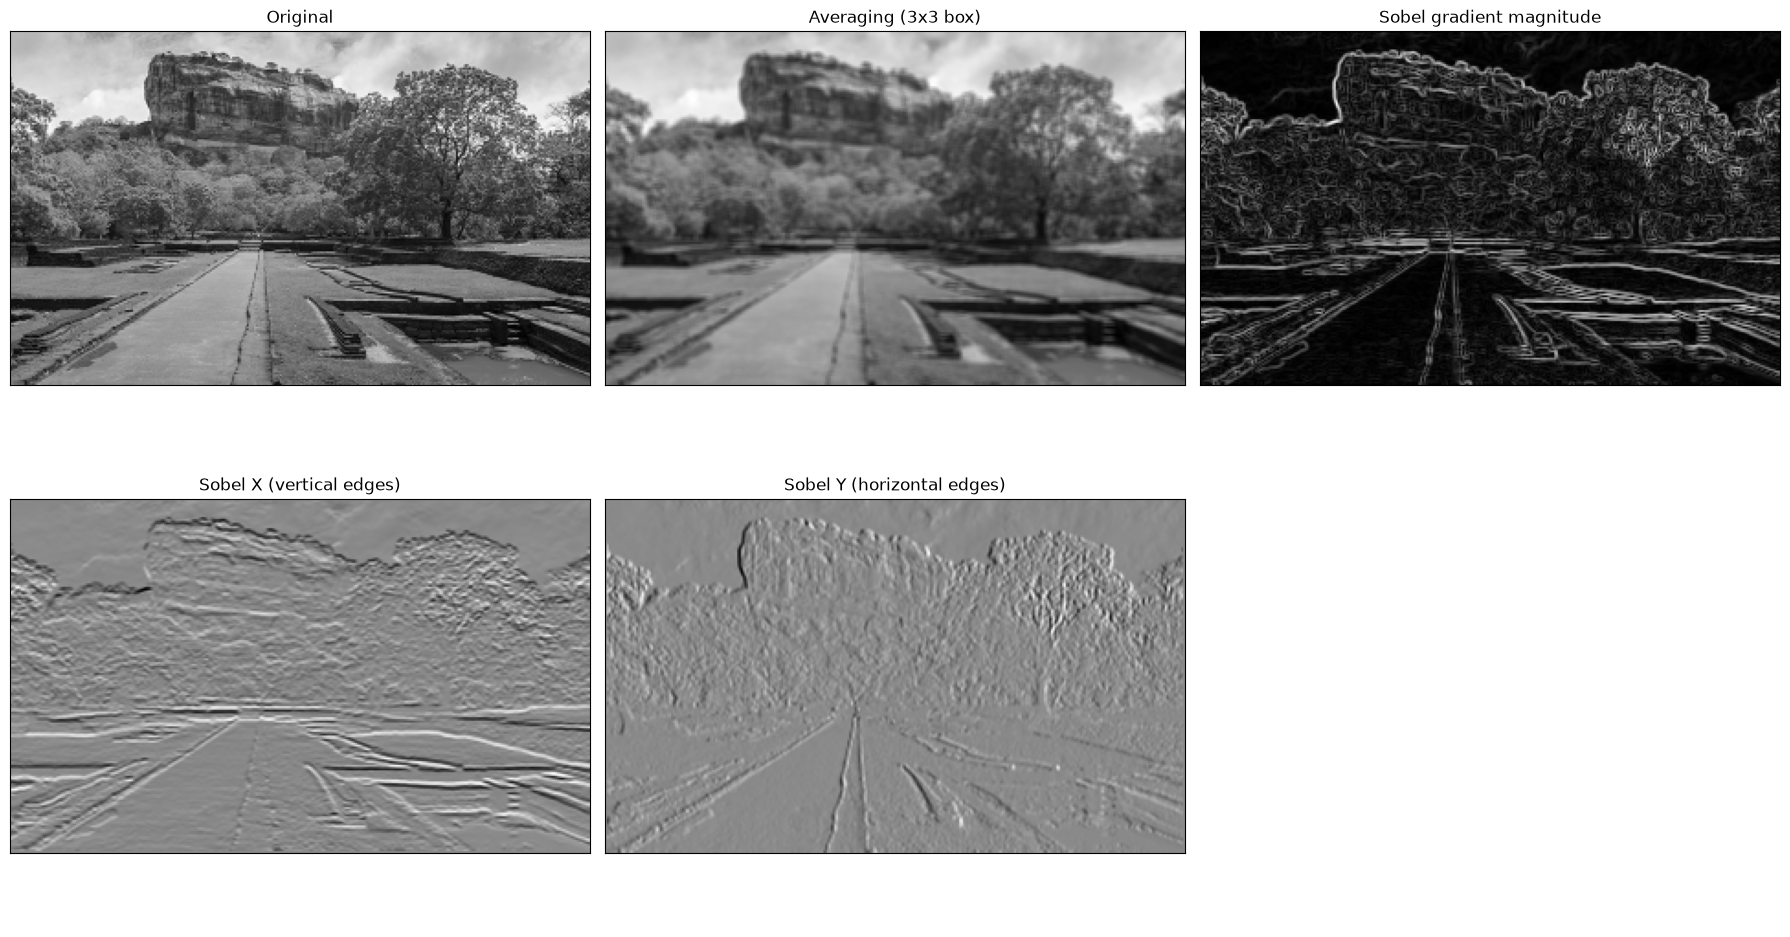

In [22]:

fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharex='all', sharey='all')
 
ax[0, 0].imshow(im, cmap='gray')
ax[0, 0].set_title('Original')
 
ax[0, 1].imshow(im_avg, cmap='gray')
ax[0, 1].set_title('Averaging (3x3 box)')
 
ax[0, 2].imshow(gradient_mag, cmap='gray')
ax[0, 2].set_title('Sobel gradient magnitude')
 
ax[1, 0].imshow(im_sobel_x, cmap='gray')
ax[1, 0].set_title('Sobel X (vertical edges)')
 
ax[1, 1].imshow(im_sobel_y, cmap='gray')
ax[1, 1].set_title('Sobel Y (horizontal edges)')
 
ax[1, 2].axis('off')  # spare subplot, unused
 
for a in ax.flat:
    a.set_xticks([]), a.set_yticks([])
 
plt.tight_layout()
plt.show()
 


#### 6. (Extra) Seeing the effect of different border/padding modes
filter2D's default border mode is BORDER_REFLECT_101 (mirror, excluding the edge pixel itself). This block lets you compare that against zero padding and edge replication side by side - watch the very edge of the image, since that's the only region where border mode has any effect at all.

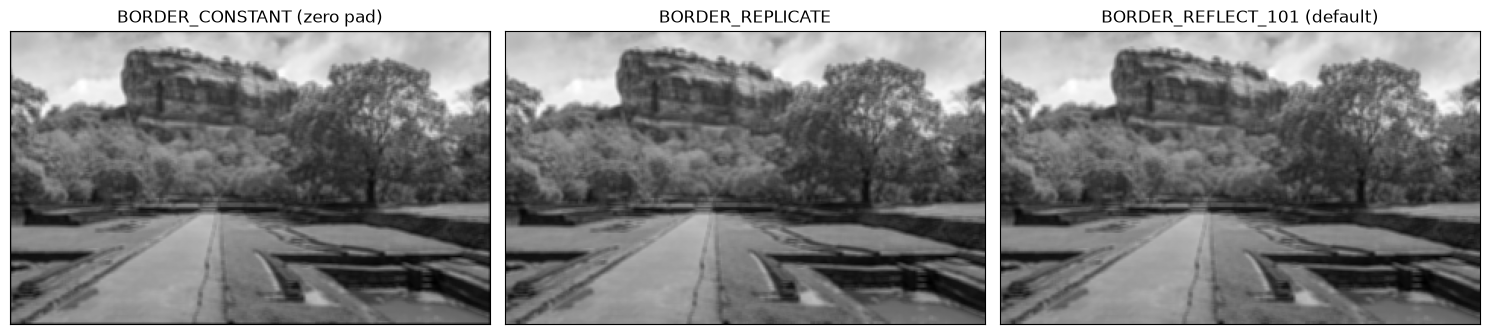

In [23]:

im_avg_zero = cv.filter2D(im, cv.CV_32F, avg_kernel, borderType=cv.BORDER_CONSTANT)
im_avg_replicate = cv.filter2D(im, cv.CV_32F, avg_kernel, borderType=cv.BORDER_REPLICATE)
im_avg_reflect101 = cv.filter2D(im, cv.CV_32F, avg_kernel, borderType=cv.BORDER_REFLECT_101)
 
fig2, ax2 = plt.subplots(1, 3, figsize=(15, 6), sharex='all', sharey='all')
ax2[0].imshow(im_avg_zero, cmap='gray')
ax2[0].set_title('BORDER_CONSTANT (zero pad)')
ax2[1].imshow(im_avg_replicate, cmap='gray')
ax2[1].set_title('BORDER_REPLICATE')
ax2[2].imshow(im_avg_reflect101, cmap='gray')
ax2[2].set_title('BORDER_REFLECT_101 (default)')
for a in ax2:
    a.set_xticks([]), a.set_yticks([])
plt.tight_layout()
plt.show()